##1.**DESCARGA DE DATOS OPEN METEO POR PUNTOS**

En esta seccion realizaremos una descarga de series de precipitacion, nubosidad, temperatura, velocidad de viento y visualizarlo

In [ ]:
!pip install openmeteo_requests
!pip install retry_requests
!pip install requests_cache

In [ ]:
#importar librerias necesarias
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry
#graficas
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

In [ ]:
#definimos funcion
def descarga_meteo(lat,lon, model):
 # Setup the Open-Meteo API client with cache and retry on error
 cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
 retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
 openmeteo = openmeteo_requests.Client(session = retry_session)
 # Make sure all required weather variables are listed here
 # The order of variables in hourly or daily is important to assign them correctly below
 url = "https://api.open-meteo.com/v1/forecast"
 params = {
    "latitude": lat,
	  "longitude": lon,
	  "hourly": ["temperature_2m", "precipitation", "cloud_cover", "wind_speed_10m"],
	  "models": model,
	  "timezone": "auto",
	  "past_days": 1,
	  "forecast_days": 7,
 }
 responses = openmeteo.weather_api(url, params=params)
 # Process first location. Add a for-loop for multiple locations or weather models
 response = responses[0]
 print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
 print(f"Elevation: {response.Elevation()} m asl")
 print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
 print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")
 #  Process hourly data. The order of variables needs to be the same as requested.
 hourly = response.Hourly()
 hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
 hourly_precipitation = hourly.Variables(1).ValuesAsNumpy()
 hourly_cloud_cover = hourly.Variables(2).ValuesAsNumpy()
 hourly_wind_speed_10m = hourly.Variables(3).ValuesAsNumpy()
 hourly_data = {"date": pd.date_range(
    start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	  end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	  freq = pd.Timedelta(seconds = hourly.Interval()),
	  inclusive = "left"
  )}

 hourly_data["temperature_2m"] = hourly_temperature_2m
 hourly_data["precipitation"] = hourly_precipitation
 hourly_data["cloud_cover"] = hourly_cloud_cover
 hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
 # --- Crear DataFrame limpio ---
 hourly_df = pd.DataFrame(data=hourly_data)

 # --- Quitar la zona horaria para que Excel no dé error ---
 hourly_df.index = pd.to_datetime(hourly_df["date"]).dt.tz_localize(None)
 #df_hh.index=pd.to_datetime(df_hh.date)
 df_hh=hourly_df.drop(columns=['date'])
 df_diario = df_hh.groupby(df_hh.index.date).agg({
      'temperature_2m': ['max', 'min'],
      'precipitation': 'sum',
     'cloud_cover': 'mean',
      'wind_speed_10m': 'max'
  })
 return df_hh, df_diario
#############################################################################

def grafica_diario(df,estacion,model):
  # --- Crear figura con 4 subplots ---
  fig, axs = plt.subplots(4, 1, figsize=(11,10), sharex=True)

  # --- 1. Temperatura ---
  axs[0].plot(df.index, df["temperature_2m"]["max"], 'ro-', label='T. Máx (°C)')
  axs[0].plot(df.index, df["temperature_2m"]["min"], 'bo-', label='T. Mín (°C)')
  for x, y in zip(df.index, df["temperature_2m"]["max"]):
     axs[0].text(x, y+0.3, f"{y:.1f}", ha='center', color='red', fontsize=9)
  for x, y in zip(df.index, df["temperature_2m"]["min"]):
     axs[0].text(x, y-0.7, f"{y:.1f}", ha='center', color='blue', fontsize=9)
  axs[0].set_ylabel("°C")
  axs[0].set_title("Temperaturas Diarias")
  axs[0].grid(True, linestyle='--', alpha=0.5)
  axs[0].legend()
  # --- 2. Precipitación ---
  axs[1].bar(df.index, df["precipitation"]["sum"], color='deepskyblue', width=0.4, label='Precipitación (mm)')
  for x, y in zip(df.index, df["precipitation"]["sum"]):
      axs[1].text(x, y+0.2, f"{y:.1f}", ha='center', fontsize=9)
  axs[1].set_ylabel("mm")
  axs[1].set_title("Precipitación Diaria")
  axs[1].grid(True, linestyle='--', alpha=0.5)
  axs[1].legend()

  # --- 3. Nubosidad ---
  axs[2].plot(df.index, df["cloud_cover"]["mean"], 's--', color='gray', label='Nubosidad (%)')
  for x, y in zip(df.index, df["cloud_cover"]["mean"]):
      axs[2].text(x, y+1, f"{y:.0f}", ha='center', color='gray', fontsize=9)
  axs[2].set_ylabel("%")
  axs[2].set_title("Cobertura Nubosa Diaria")
  axs[2].grid(True, linestyle='--', alpha=0.5)
  axs[2].legend()
  # --- 4. Viento máximo ---
  axs[3].plot(df.index, df["wind_speed_10m"]["max"], 'g^-', label='Viento Máx (km/h)')
  for x, y in zip(df.index, df["wind_speed_10m"]["max"]):
     axs[3].text(x, y+0.5, f"{y:.1f}", ha='center', color='green', fontsize=9)
  axs[3].set_ylabel("km/h")
  axs[3].set_title("Viento Máximo Diario")
  axs[3].grid(True, linestyle='--', alpha=0.5)
  axs[3].legend()
  fig.suptitle(f'Meteograma diario: {estacion}, Model: {model}', fontsize=14, weight='bold')
  # --- Estética final ---
  plt.xticks(rotation=45)
  plt.xlabel("Fecha")
  plt.tight_layout()
  plt.show()

#######################################################################################################################DINAMICO
def grafica_horaria(df,estacion,model):
#estacion="Cochabamba Aeropuerto"
#df=df_hh.copy()

  # Crear subplots
  fig = make_subplots(
      rows=4, cols=1,
      subplot_titles=('Temperatura (°C)', 'Precipitación (mm)', 'Cobertura de Nubes (%)', 'Velocidad del Viento (km/h)'),
      vertical_spacing=0.08,
      shared_xaxes=True
  )

  # Agregar trazas usando el índice como eje X
  fig.add_trace(
      go.Scatter(x=df.index, y=df['temperature_2m'],
                 name='Temperatura', line=dict(color='red')),
      row=1, col=1
  )

  fig.add_trace(
      go.Bar(x=df.index, y=df['precipitation'],
             name='Precipitación',
             marker_color='blue',
             marker_line_color='darkblue',  # Borde de las barras
             marker_line_width=1,           # Grosor del borde
            opacity=0.7),                  # Transparencia
      row=2, col=1
  )

  fig.add_trace(
      go.Scatter(x=df.index, y=df['cloud_cover'],
                 name='Cobertura de Nubes', line=dict(color='gray')),
      row=3, col=1
  )

  fig.add_trace(
      go.Scatter(x=df.index, y=df['wind_speed_10m'],
                 name='Velocidad del Viento', line=dict(color='green')),
      row=4, col=1
  )

  # Actualizar layout
  fig.update_layout(
      title=f'SERVICIO NACIONAL DE METEROLOGIA E HIDROLOGIA<br> Pronostico en estacion:{estacion}, Model: {model}',
      height=800,
      showlegend=True,
      template='plotly_white'
  )

  # Actualizar ejes Y para cada subplot
  fig.update_yaxes(title_text="°C", row=1, col=1)
  fig.update_yaxes(title_text="mm", row=2, col=1)
  fig.update_yaxes(title_text="%", row=3, col=1)
  fig.update_yaxes(title_text="km/s", row=4, col=1)
  # Actualizar eje X compartido
  fig.update_xaxes(title_text="Hora", row=4, col=1)
  fig.show()


**APLICANDO METEGRAM DIARIO**

In [2]:
#CONDICIONES INICIALES pone el usuario departamental############################################33
#"icon_seamless", "gfs_seamless" "ecmwf"
estacion="YACUIBA" ##solo nombre
model="gfs_seamless"
lat=-22.0164
lon=-63.6775


In [3]:
#PLICAMOS LA FUNCION
df_hh,df_diario=descarga_meteo(lat,lon,model)

NameError: name 'descarga_meteo' is not defined

In [ ]:
df_hh.head()

,temperature_2m,precipitation,cloud_cover,wind_speed_10m
date,,,,
2025-10-16 04:00:00,16.164,0.0,10.0,3.758510
2025-10-16 05:00:00,15.564,0.0,8.0,2.620839
2025-10-16 06:00:00,15.414,0.0,6.0,3.893995
2025-10-16 07:00:00,14.864,0.0,100.0,3.319036
2025-10-16 08:00:00,14.514,0.0,98.0,2.545584


In [ ]:
df_diario.head()

temperature_2m         precipitation cloud_cover wind_speed_10m
                      max     min           sum        mean            max
2025-10-16      25.464001  13.764           0.0   61.900002      37.923225
2025-10-17      27.664000  14.364           0.4   53.666668      31.565245
2025-10-18      25.664000  12.164          12.2   97.541664      22.870626
2025-10-19      22.764000  12.164           5.2   84.708336      23.219301
2025-10-20      25.264000  14.414           0.2   86.375000      32.688713

**APLICANDO METEOGRAMA HORARIO DINAMICO**

In [4]:
grafica_horaria(df_hh,estacion,model)

NameError: name 'grafica_horaria' is not defined

***METEOGRAMA DIARIO***

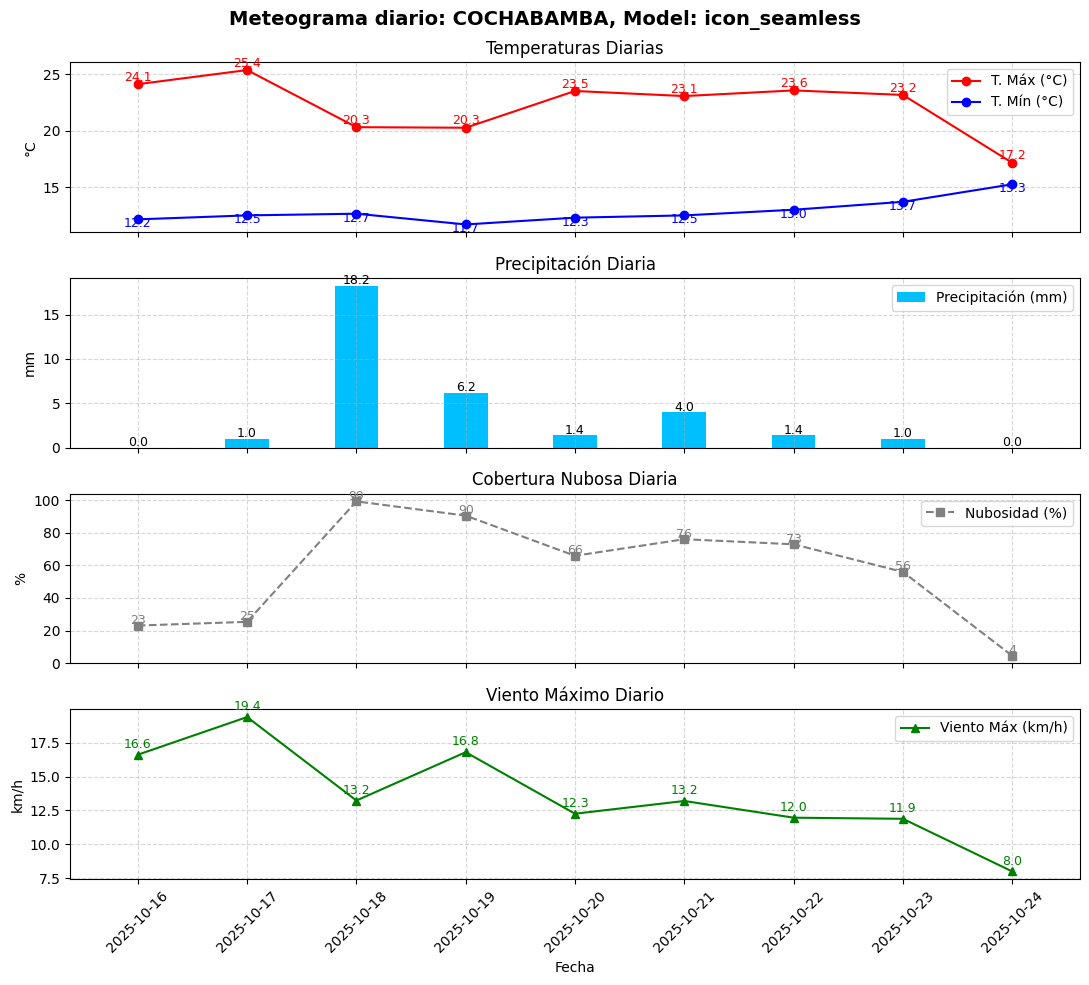

In [ ]:
grafica_diario(df_diario,estacion,model)

# **CALIBRACION INMEDIATA**
#  Métodos de Calibración para Temperatura

La **calibración de temperatura** busca corregir los sesgos entre los datos **observados** (por estaciones meteorológicas) y los **estimados o simulados** (por modelos climáticos o satelitales).  
Estos métodos mejoran la precisión y representatividad de los datos a nivel local.

---

## 🔹 1. Métodos Estadísticos Simples

### 🔸 Corrección Lineal (Bias Correction)
Ajusta los valores estimados mediante una relación lineal:

$$
T_{corr} = a + b \times T_{mod}
$$

donde *a* y *b* se obtienen mediante regresión lineal entre los datos observados y los del modelo.

### 🔸 Ajuste de Sesgo Promedio (Mean Bias Adjustment)
Corrige la diferencia promedio entre datos observados y simulados:

$$
T_{corr} = T_{mod} - (\bar{T}_{mod} - \bar{T}_{obs})
$$

---

## 🔹 2. Métodos de Emparejamiento de Distribuciones

### 🔸 Quantile Mapping (QM)
Ajusta no solo la media, sino toda la **distribución** de los datos.  
Se igualan los cuantiles del modelo a los cuantiles observados, manteniendo la variabilidad local.

> Muy utilizado para corregir salidas de modelos climáticos o WRF.

---

## 🔹 3. Métodos de Aprendizaje Automático (Machine Learning)

- **Regresión múltiple:** incorpora variables como altitud, latitud, pendiente, etc.  
- **Árboles de decisión y ensambles (Random Forest, XGBoost):** capturan relaciones no lineales entre observaciones y simulaciones.  
- **Redes neuronales:** útiles con grandes volúmenes de datos y relaciones complejas.

---

## 🔹 4. Métodos Espaciales

- **Kriging o regresión espacial:** integran información espacial (altitud, pendiente, orientación) para generar campos calibrados.  
- **Downscaling estadístico:** ajusta los valores del modelo global o regional a resoluciones locales considerando factores topográficos.

---

##  Resumen

| Tipo de método | Características principales | Complejidad |
|----------------|-----------------------------|--------------|
| Estadísticos simples | Corrigen sesgos medios | Baja |
| Quantile Mapping | Ajustan toda la distribución | Media |
| Machine Learning | Capturan relaciones no lineales | Alta |
| Espaciales | Consideran topografía y ubicación | Media-Alta |

---




In [ ]:
df_diario.head()

temperature_2m            precipitation cloud_cover wind_speed_10m
                      max        min           sum        mean            max
2025-10-16      24.130501  12.180500      0.000000   23.049999      16.622490
2025-10-17      25.380501  12.530499      1.000000   25.333334      19.406637
2025-10-18      20.330502  12.680500     18.200001   99.250000      13.237039
2025-10-19      20.280500  11.730500      6.200000   90.500000      16.808569
2025-10-20      23.530500  12.330500      1.400000   65.875000      12.261158

In [ ]:
#tendencias
df_mod = df_diario.iloc[1:-1]
df_mod.head()


temperature_2m            precipitation cloud_cover wind_speed_10m
                      max        min           sum        mean            max
2025-10-17      25.380501  12.530499      1.000000   25.333334      19.406637
2025-10-18      20.330502  12.680500     18.200001   99.250000      13.237039
2025-10-19      20.280500  11.730500      6.200000   90.500000      16.808569
2025-10-20      23.530500  12.330500      1.400000   65.875000      12.261158
2025-10-21      23.080502  12.530499      4.000000   76.041664      13.202726

In [ ]:
#dato medido en cochabmaba aeropuerto######
TMAX_INSITU=28
TMIN_INSITU=12
##################################################################3
df_mod["temperature_2m"]["max"].diff() + TMAX_INSITU

,max
2025-10-17,NaN
2025-10-18,22.950001
2025-10-19,27.949999
2025-10-20,31.250000
2025-10-21,27.550001
2025-10-22,28.500000
2025-10-23,27.599998


In [ ]:
df_mod["temperature_2m"]["min"].diff() +TMIN_INSITU

,min
2025-10-17,NaN
2025-10-18,12.150001
2025-10-19,11.050000
2025-10-20,12.599999
2025-10-21,12.200000
2025-10-22,12.500000
2025-10-23,12.700001
